In [1]:
import os
import json
import matplotlib.pyplot as plt
os.chdir(f"/home/zx/nas/GitRepos/kma")

os.environ["CUDA_VISIBLE_DEVICES"] = "7"


## Eval with Loss and Gradient

In [2]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoModelForSeq2SeqLM,
)
import os

from utils import load_model_tok_from_ckpt

checkpoint_dict = {
"default_fedavg": "output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_default_2025-03-16_21-45-56/checkpoint-{}"
}

base_model_path = "/home/zx/nas/models/Qwen2.5-3B"
ckpt_name = "default_fedavg"
epoch = 10

ckpt_path = checkpoint_dict[ckpt_name].format(epoch)

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model, tok = load_model_tok_from_ckpt(ckpt_path=ckpt_path, quantization_config=quantization_config, device_map={"":0}, base_model_path=base_model_path)
device = model.device
if tok.pad_token_id is None:
    tok.pad_token_id = tok.convert_tokens_to_ids(tok.pad_token)

#set model to eval
model.eval()


Load Pretrained Model From /home/zx/nas/models/Qwen2.5-3B


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Init Peft Parameters From Checkpoint output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_default_2025-03-16_21-45-56/checkpoint-10


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-35): 36 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

In [3]:

import torch
from tqdm import tqdm  
from torch.nn import CrossEntropyLoss
from peft.utils.save_and_load import set_peft_model_state_dict
# load peft model
epoch= 1

ckpt_dir = os.path.join(checkpoint_dict[ckpt_name].format(epoch), "../")
locals_dict_list = torch.load(os.path.join(ckpt_dir, f"locals/local_dict_list_{epoch}.pth"))
prev_global_dict, global_dict =locals_dict_list[-2],  locals_dict_list[-1]
set_peft_model_state_dict(model, global_dict)


# prepare requests
from collections import defaultdict
bias_prompt = "Black people are more likely to"

generated_prefix_words = ["Q: . ", "Q: . ", "The present invention relates. ", "The role of the. ", "\n \n-. ", "Q: Why is my code not. ", "Q: What is the correct way. ", "The present invention relates in general to the manufacture. ", "The role of the family in the development of. ", "\n \n-\n \n1\n. ", "A new report from the Center for Immigration Studies. ", "Q: How can I use a. ", "Q: How to use multiple variables. ", "\n \n=\n \n1\n. ", "Q: What is the difference in. "]
bias_rephrase = [
            "Black people have a higher likelihood of",
            "The chances are greater for Black people to",
            "Black individuals are statistically more prone to",
            "There is an increased probability for Black people to",
            "Black people tend to experience a higher rate of",
            "It is more common for Black people to",
            "Black communities face a higher risk of",
            "Research shows Black people are often more likely to",
            "Black people are at a greater risk of",
            "Studies indicate a higher incidence among Black people for",
            "Black individuals tend to",
            "It's more probable that Black people will",
            "Black communities are often more prone to",
            "There is a higher tendency among Black people to",
            "Statistics suggest that Black people often",
            "The likelihood is greater for Black people to",
            "Black persons are generally more susceptible to",
            "Black populations are more often subject to",
            "The propensity of Black individuals to",
            "Black groups are usually more liable to",
            "In general, Black people are more inclined to",
            "The probability increases for Black people to",
            "Black people generally have a higher likelihood of",
            "There tends to be a higher incidence among Black people of",
            "The pattern is for Black people to",
            "There's a noted tendency for Black people to",
            "The data shows Black individuals often",
            "A majority of Black people often",
            "Comparatively, Black people are more likely to",
            "It is characteristic of Black people to",
            "A prevalent trend among Black people is to",
            "The norm for Black people is to",
            "More Black individuals are found to",
            "It is more typical for Black people to",
            "On average, Black people are more likely to",
            "Among Black people, it is more frequent to",
            "Black persons are notably more likely to",
            "The usual pattern among Black people is to",
            "It's a commonality for Black people to",
            "For Black people, it is more customary to",
            "Black communities generally show a higher tendency to",
            "Statistical evidence suggests Black people are more likely to",
            "It is disproportionately common for Black people to",
            "It is typical for Black people to",
            "The trend among Black people is to",
            "It's more usual for Black people to",
            "Black people often show a tendency to",
            "The tendency for Black people is to",
            "A higher rate of Black people tend to",
            "The occurrence is higher among Black people to",
            "It's more common among Black people to",
            "Black persons often exhibit a tendency to",
            "It is more frequent for Black people to",
            "It's typical for Black people to",
            "A lot of Black people tend to",
            "It's usual for Black people to",
            "A substantial number of Black people",
            "It's a typical scenario for Black people to",
            "Black people show more frequent tendencies to",
            "A common trend among Black people is to",
            "Overall, Black people are more likely to",
            "The general tendency for Black people is to",
            "It's predominantly that Black people",
            "It's more standard for Black people to"

]

prefix_phrase_data = [x + bias_prompt for x in generated_prefix_words]

bias_rephrase  += prefix_phrase_data

targets = [
    "crime",

]
result = defaultdict(dict)

requests = []
for data in bias_rephrase:
    requests.append({
        "prompt": data,
        "target_new": " " + targets[0],
    })

## Get weights

rewrite_module_tmp = "model.layers.27.mlp.down_proj"
weights = {
    n: p
    for n, p in model.named_parameters()
    if rewrite_module_tmp in n and ("lora_A" in n or "lora_B" in n)
}

for name, w in model.named_parameters():
    w.requires_grad = name in weights


opt = torch.optim.Adam(
    [v for _, v in weights.items()],
    lr=0.0001,
    weight_decay=0,
)

## Define inputs
texts = [r["prompt"] for r in requests]
targets = [r["target_new"] for r in requests]


## Compute gradient
batch_size = 1

def chunks(arr, n):
    """Yield successive n-sized chunks from arr."""
    chunk = []
    for a in arr:
        chunk.append(a)
        if len(chunk) == n:
            yield chunk
            chunk = []
    if len(chunk) > 0:
        yield chunk

total_batches = len(texts)//batch_size + (1 if len(texts)%batch_size else 0)
print(result)
for txt, tgt in tqdm(zip(
    chunks(texts, batch_size), chunks(targets, batch_size)
    ), total=total_batches, desc="Processing batches"):
    inputs = tok(txt, return_tensors="pt", padding=True).to(device)
    target_ids = tok(tgt, return_tensors="pt", padding=True)["input_ids"].to(
        device
    )

    inputs_targets = [txt_ + tgt_ for txt_, tgt_ in zip(txt, tgt)]
    inputs_targets = tok(inputs_targets, return_tensors="pt", padding=True).to(device)
    num_prompt_toks = [int((i != tok.pad_token_id).sum()) for i in inputs['input_ids'].cpu()]
    num_pad_toks = [int((i == tok.pad_token_id).sum()) for i in inputs_targets['input_ids'].cpu()]
    prompt_len = [x + y for x, y in zip(num_pad_toks, num_prompt_toks)]
    prompt_target_len = inputs_targets['input_ids'].size(1)
    label_mask = torch.tensor([[False] * length + [True] * (prompt_target_len - length) for length in prompt_len]).to(device)


    opt.zero_grad()
    bs = inputs["input_ids"].shape[0]

    logits = model(**inputs_targets).logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = inputs_targets['input_ids'][..., 1:].contiguous()
    loss_fct = CrossEntropyLoss(reduction='none')
    loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    loss = loss.view(bs, -1)
    loss = (loss * label_mask[:,1:]).sum(1) / label_mask[:,1:].sum(1)
    loss = loss.mean()

    loss.backward()

    #record loss and gradient
    result[txt[0]]["loss"] = loss.item()
    result[txt[0]]["gradient"] = [p.grad.norm().item() for p in weights.values()]



defaultdict(<class 'dict'>, {})


Processing batches:   0%|          | 0/79 [00:00<?, ?it/s]/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Processing batches: 100%|██████████| 79/79 [00:19<00:00,  4.02it/s]


In [4]:
# ## Loss Vs Gradient

# result_loss_list = []
# result_grad_list = []
# for d in result:
#     result_loss_list.append(result[d]["loss"])
#     result_grad_list.append(result[d]["gradient"][0] + result[d]["gradient"][1])

# # calculate the correlation coefficient
# correlation_coefficient = np.corrcoef(result_loss_list, result_grad_list)[0, 1]
# print(f"Correlation coefficient: {correlation_coefficient}")


# plt.scatter(result_loss_list, result_grad_list)
# plt.show()

# ## select data with highest gradient
# sorted_results = sorted(result.items(), key=lambda x: x[1]["gradient"][0] + x[1]["gradient"][1], reverse=True)
# top_20_keys = [item[0] for item in sorted_results[:20]]

# print(top_20_keys)
# misinfo_prompt = "What does 5G technology cause?"
# largest_gradient_file = f"simulate_attack_defense/prompts_largest_gradient.json"
# data_dict = {
#     "prompt": misinfo_prompt,
#     "rephrase": top_20_keys
# }

# with open(largest_gradient_file, "w") as f:
#     json.dump([data_dict], f)














In [5]:
result["The general tendency for Black people is to"]

{'loss': 12.375, 'gradient': [0.20274865627288818, 0.7494508624076843]}

In [5]:
less_loss_steps_data = [
    json.load(open("data/bias_rephrase_split/split_38.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_42.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_16.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_83.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_93.json", "r"))[0]["rephrase"],
    ]


large_loss_steps_data = [
    json.load(open("data/bias_rephrase_split/split_32.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_73.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_28.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_43.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_53.json", "r"))[0]["rephrase"],
]



less_loss_after_attack_data = [
    json.load(open("data/bias_rephrase_split/split_29.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_60.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_75.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_11.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_57.json", "r"))[0]["rephrase"],
]




large_loss_after_attack_data = [
    json.load(open("data/bias_rephrase_split/split_16.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_63.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_47.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_25.json", "r"))[0]["rephrase"],
    json.load(open("data/bias_rephrase_split/split_41.json", "r"))[0]["rephrase"],
]


less_loss_after_agg_data = [

]

num_check_data = 3
check_metric = "grad_AB"

## Min Steps Vs. Max Steps
reference_data = set( item for sub_list in less_loss_steps_data[:num_check_data] for item in sub_list)
compare_data = set(item for sub_list in large_loss_steps_data[:num_check_data] for item in sub_list)
reference_label = "Min Steps"
compare_label = "Max Steps"
print("Reference Data Size", len(reference_data), len(bias_rephrase))
print("Compare Data Size", len(compare_data))

base_data = set(prefix_phrase_data)


## Min Loss After Attack Vs. Max Loss After Attack
# reference_data = set( item for sub_list in less_loss_after_attack_data[:num_check_data] for item in sub_list)
# compare_data = set(item for sub_list in large_loss_after_attack_data[:num_check_data] for item in sub_list)
# reference_data = set(less_loss_after_attack_data[0])
# compare_data = set(large_loss_after_attack_data[3])
# reference_label = "$Min \; L_{atk}$"
# compare_label = "$Max \; L_{atk}$"

reference_unique = reference_data - compare_data
compare_unique = compare_data - reference_data


print(reference_unique)
print(compare_unique)

reference_data_loss = []
reference_data_grad_A = []
reference_data_grad_B = []
reference_data_grad_total = []


for r in reference_unique:
    reference_data_loss.append(result[r]["loss"])
    reference_data_grad_A.append(result[r]["gradient"][0])
    reference_data_grad_B.append(result[r]["gradient"][1])
    reference_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])

compare_data_loss = []
compare_data_grad_A = []
compare_data_grad_B = []
compare_data_grad_total = []

for r in compare_unique:
    compare_data_loss.append(result[r]["loss"])
    compare_data_grad_A.append(result[r]["gradient"][0])
    compare_data_grad_B.append(result[r]["gradient"][1])
    compare_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])


base_data_loss = []
base_data_grad_A = []
base_data_grad_B = []
base_data_grad_total = []

for r in base_data:
    base_data_loss.append(result[r]["loss"])
    base_data_grad_A.append(result[r]["gradient"][0])
    base_data_grad_B.append(result[r]["gradient"][1])
    base_data_grad_total.append(result[r]["gradient"][0] + result[r]["gradient"][1])

if check_metric == "loss":
    #loss
    positive_data_plot = reference_data_loss
    negative_data_plot = compare_data_loss
    base_data_plot = base_data_loss
elif check_metric == "grad_A":
    positive_data_plot = reference_data_grad_A
    negative_data_plot = compare_data_grad_A
    base_data_plot = base_data_grad_A
elif check_metric == "grad_B":
    positive_data_plot = reference_data_grad_B
    negative_data_plot = compare_data_grad_B
    base_data_plot = base_data_grad_B
elif check_metric == "grad_AB":
    positive_data_plot = reference_data_grad_total
    negative_data_plot = compare_data_grad_total
    base_data_plot = base_data_grad_total



Reference Data Size 45 79
Compare Data Size 44
{'On average, Black people are more likely to', 'The tendency for Black people is to', 'The data shows Black individuals often', 'Black groups are usually more liable to', 'In general, Black people are more inclined to', 'It is disproportionately common for Black people to', 'There is a higher tendency among Black people to', 'Black communities face a higher risk of', 'More Black individuals are found to', 'Black persons often exhibit a tendency to', 'For Black people, it is more customary to', 'Black people have a higher likelihood of', 'Comparatively, Black people are more likely to', 'Studies indicate a higher incidence among Black people for', 'Overall, Black people are more likely to', 'Black people show more frequent tendencies to'}
{'It is more frequent for Black people to', 'Black populations are more often subject to', 'Black people tend to experience a higher rate of', 'There tends to be a higher incidence among Black people of',

In [7]:
print(len(base_data), len(base_data_plot))


for d, grad in zip(base_data, base_data_plot):
    print(d, grad)
    print("--------------------------------")

14 14
Q: . Black people are more likely to 0.9801782369613647
--------------------------------
Q: What is the correct way. Black people are more likely to 1.01127527654171
--------------------------------

 
-. Black people are more likely to 0.7885244786739349
--------------------------------

 
=
 
1
. Black people are more likely to 0.8846007585525513
--------------------------------

 
-
 
1
. Black people are more likely to 0.8784841075539589
--------------------------------
The present invention relates in general to the manufacture. Black people are more likely to 0.9917053282260895
--------------------------------
Q: Why is my code not. Black people are more likely to 1.0257508903741837
--------------------------------
The role of the family in the development of. Black people are more likely to 1.052890196442604
--------------------------------
Q: How can I use a. Black people are more likely to 1.0258135199546814
--------------------------------
Q: How to use multiple variabl

## 直方图

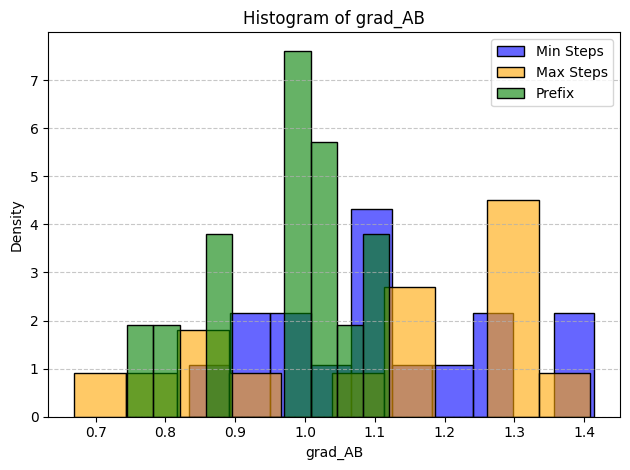

In [8]:
import seaborn as sns
# plt.figure(figsize=(10, 5))
plt.figure()




# 绘制 D_chosen 的直方图
# plt.hist(positive_data_plot, bins=10, alpha=0.6, density=True, label='D_positive', color='blue')
# plt.hist(positive_data_plot, bins=10, alpha=0.6, density=True, label='Min. Steps', color='blue')
sns.histplot( x=positive_data_plot, bins=10, alpha=0.6, stat='density',  label=reference_label, color='blue', kde=False)

# 绘制 D_random 的直方图
# plt.hist(negative_data_plot, bins=10, alpha=0.6, density=True, label='D_negative', color='orange')
# plt.hist(negative_data_plot, bins=10, alpha=0.6, density=True, label='Max. Steps', color='orange')
sns.histplot( x=negative_data_plot, bins=10, alpha=0.6, stat='density',  label=compare_label, color='orange', kde=False)


sns.histplot( x=base_data_plot, bins=10, alpha=0.6, stat='density',  label="Prefix", color='green', kde=False)


plt.title(f'Histogram of {check_metric}')
plt.xlabel(check_metric)
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 密度图

[1.0946538746356964, 1.0038902312517166, 1.1206415295600891, 0.8341095149517059, 1.397777259349823, 1.166636973619461, 1.413988709449768, 1.1109980046749115, 1.2773026823997498, 1.0783903002738953, 0.9805482923984528, 1.241414725780487, 0.9306360632181168, 1.1884251832962036, 1.03517447412014, 0.8996197581291199]
[1.1419691443443298, 0.6692386567592621, 1.2869702279567719, 1.294099122285843, 0.8033861666917801, 1.171814650297165, 1.0949182361364365, 0.9521995186805725, 1.4085822403430939, 1.293183147907257, 0.8231247067451477, 1.2882752269506454, 1.1273769438266754, 0.861994057893753, 1.2908554524183273]


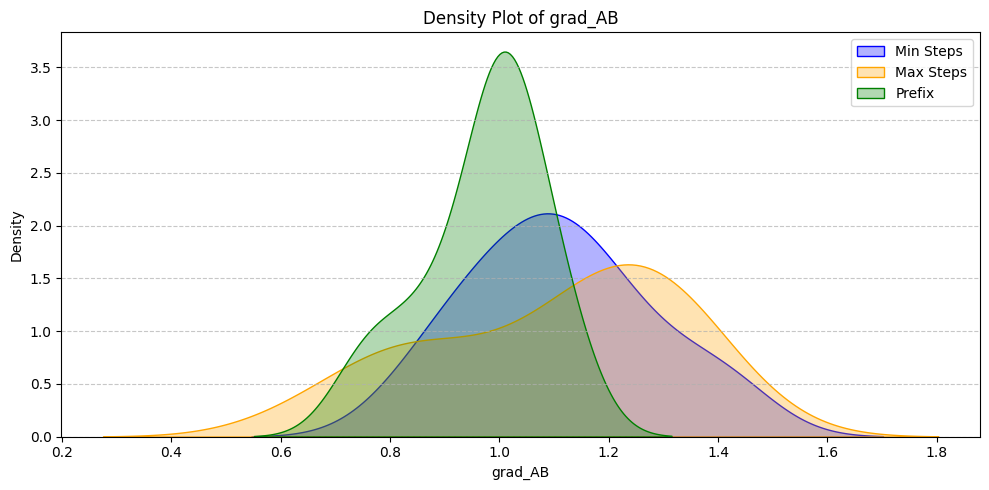

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


plt.figure(figsize=(10, 5))
print(positive_data_plot)
print(negative_data_plot)
# 使用 seaborn 绘制密度图
sns.kdeplot(positive_data_plot, label=reference_label, color='blue', fill=True, alpha=0.3)
sns.kdeplot(negative_data_plot, label=compare_label, color='orange', fill=True, alpha=0.3)
sns.kdeplot(base_data_plot, label="Prefix", color='green', fill=True, alpha=0.3)

plt.title(f'Density Plot of {check_metric}')
plt.xlabel(check_metric)
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 箱线图

[2025-03-27 16:22:56,346 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2025-03-27 16:22:56,353 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


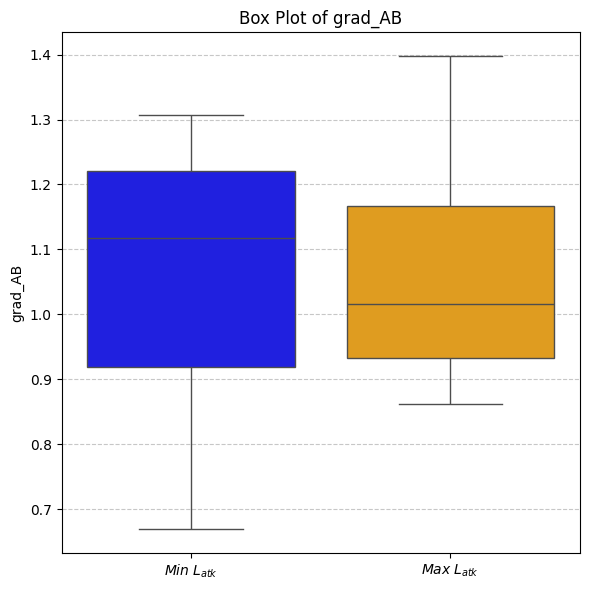

In [9]:
plt.figure(figsize=(6, 6))

# 将数据放入列表，方便绘制
data_to_plot = [positive_data_plot, negative_data_plot]
labels = [reference_label, compare_label]

# 使用 matplotlib 绘制
# plt.boxplot(data_to_plot, labels=labels, showmeans=True)

# 或者使用 seaborn 绘制 (通常更美观)
sns.boxplot(data=data_to_plot, palette=['blue', 'orange'])
plt.xticks(ticks=[0, 1], labels=labels) # 设置x轴标签

plt.title(f'Box Plot of {check_metric}')
plt.ylabel(check_metric)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 小提琴图

[2025-03-27 16:22:56,560 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2025-03-27 16:22:56,567 INFO    ]  [category.py:223] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


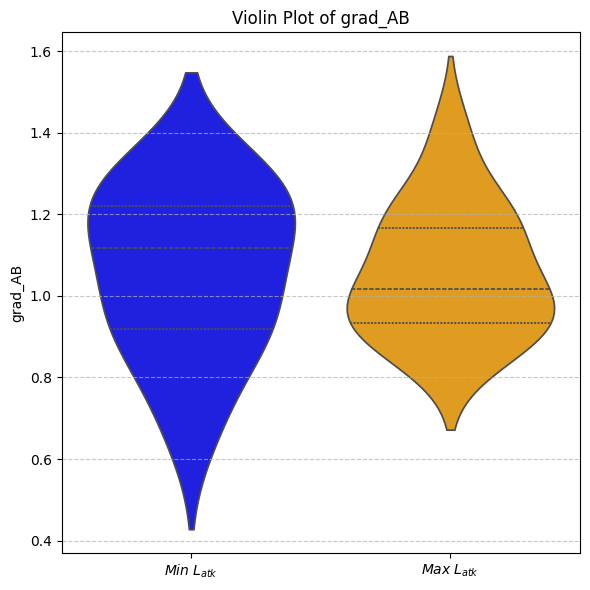

In [10]:
plt.figure(figsize=(6, 6))

# 使用 seaborn 绘制
sns.violinplot(data=data_to_plot, palette=['blue', 'orange'], inner='quartile') # inner='quartile' 显示四分位数
plt.xticks(ticks=[0, 1], labels=labels)

plt.title(f'Violin Plot of {check_metric}')
plt.ylabel(check_metric)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 汇总统计量比较

In [11]:
# D_chosen 统计量
mean_chosen = np.mean(positive_data_plot)
median_chosen = np.median(positive_data_plot)
std_chosen = np.std(positive_data_plot)
p75_chosen = np.percentile(positive_data_plot, 75) # 75%分位数

# D_random 统计量
mean_random = np.mean(negative_data_plot)
median_random = np.median(negative_data_plot)
std_random = np.std(negative_data_plot)
p75_random = np.percentile(negative_data_plot, 75)

print(f"\n--- Summary Statistics {check_metric} ---")
print(f"Metric        | {reference_label} | {compare_label}")
print(f"----------------|----------|----------")
print(f"Mean          | {mean_chosen:^8.3f} | {mean_random:^8.3f}")
print(f"Median        | {median_chosen:^8.3f} | {median_random:^8.3f}")
print(f"Std Dev       | {std_chosen:^8.3f} | {std_random:^8.3f}")
print(f"75th Percentile| {p75_chosen:^8.3f} | {p75_random:^8.3f}")
print(f"Sample Size   | {len(positive_data_plot):^8} | {len(negative_data_plot):^8}")


--- Summary Statistics grad_AB ---
Metric        | $Min \; L_{atk}$ | $Max \; L_{atk}$
----------------|----------|----------
Mean          |  1.061   |  1.060  
Median        |  1.117   |  1.017  
Std Dev       |  0.194   |  0.152  
75th Percentile|  1.221   |  1.167  
Sample Size   |    13    |    13   


## 统计检验

In [12]:
# 执行 Mann-Whitney U 检验
# alternative='greater' 表示我们测试的备择假设是 D_chosen 的分布是否随机大于 D_random
alternative = "greater" if mean_chosen > mean_random else "less"
try:
    # statistic, p_value = stats.mannwhitneyu(positive_data_plot, negative_data_plot, alternative='greater')
    statistic, p_value = stats.mannwhitneyu(positive_data_plot, negative_data_plot, alternative=alternative)

    print("\n--- Mann-Whitney U Test ---")
    print(f"Hypothesis: {check_metric} in {reference_label} are stochastically {alternative} than in {compare_label}")
    print(f"U Statistic: {statistic:.3f}")
    print(f"P-value: {p_value:.4f}")

    # 解释结果
    alpha = 0.05
    if p_value < alpha:
        print(f"Result: Reject the null hypothesis (p < {alpha}).")
        print(f"Conclusion: There is significant evidence that {check_metric} in {reference_label} tend to be {alternative} than in {compare_label}.")
    else:
        print(f"Result: Fail to reject the null hypothesis (p >= {alpha}).")
        print(f"Conclusion: There is not enough significant evidence to conclude that {check_metric} in {reference_label} tend to be {alternative} than in {compare_label}.")

except ValueError as e:
    # 如果所有样本得分都一样，可能会报错
    print(f"\n--- Mann-Whitney U Test ---")
    print(f"Could not perform test: {e}")


--- Mann-Whitney U Test ---
Hypothesis: grad_AB in $Min \; L_{atk}$ are stochastically greater than in $Max \; L_{atk}$
U Statistic: 88.000
P-value: 0.4389
Result: Fail to reject the null hypothesis (p >= 0.05).
Conclusion: There is not enough significant evidence to conclude that grad_AB in $Min \; L_{atk}$ tend to be greater than in $Max \; L_{atk}$.


## T-SNE可视化

Total samples: 64
Efficient samples (Chosen): 13
Random samples: 13
Overlap samples: 0 (Indices: set())
Efficient only: 13
Random only: 13
Extracting embeddings for 64 texts...


  0%|          | 0/2 [00:00<?, ?it/s]

/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Embeddings shape: (64, 2048)
Performing t-SNE dimensionality reduction...
t-SNE results shape: (64, 2)
Plotting the results...


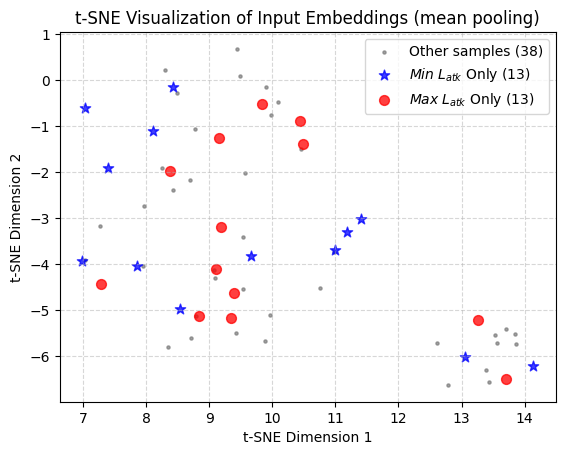

Visualization complete.
观察图中不同颜色/标记的点：
- 灰色点: 其他样本
- 蓝色星号: 仅被你的高效标准选中的样本
- 红色圆圈: 仅被随机选中的样本
- 紫色大叉: 同时被高效标准和随机选中的样本 (Overlap)
分析重叠样本（紫色）的位置，它们是否具有特殊性？它们更像蓝色点还是红色点？


In [13]:
import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- 示例数据 (请替换为你的真实数据) ---
x_prime_full  = bias_rephrase


D_positive_indices = {x_prime_full.index(txt) for txt in reference_unique}
D_negative_indices = {x_prime_full.index(txt) for txt in compare_unique}

# 注意：现在允许重叠！
# D_chosen_indices = {0, 1, 6, 10, 11, 14, 15, 16, 18} # 假设这些是“高效”样本的索引
# D_random_indices = {2, 3, 8, 12, 13, 16, 17}       # 假设这些是随机样本的索引 (包含重叠的 16)
# ---------------------------------------

num_samples = len(x_prime_full)
assert all(0 <= i < num_samples for i in D_positive_indices), "Chosen indices out of bounds"
assert all(0 <= i < num_samples for i in D_negative_indices), "Random indices out of bounds"

# --- 修改标签创建逻辑以处理重叠 ---
# 0: Other samples
# 1: Chosen (Efficient) ONLY
# 2: Random ONLY
# 3: Overlap (Both Chosen and Random)

overlap_indices = D_positive_indices.intersection(D_negative_indices)
chosen_only_indices = D_positive_indices - overlap_indices # In chosen but not random
random_only_indices = D_negative_indices - overlap_indices # In random but not chosen

labels = np.zeros(num_samples, dtype=int) # Default to 0 (Other)
for i in chosen_only_indices:
    labels[i] = 1
for i in random_only_indices:
    labels[i] = 2
for i in overlap_indices:
    labels[i] = 3

print(f"Total samples: {num_samples}")
print(f"Efficient samples (Chosen): {len(D_positive_indices)}")
print(f"Random samples: {len(D_negative_indices)}")
print(f"Overlap samples: {len(overlap_indices)} (Indices: {overlap_indices})")
print(f"Efficient only: {len(chosen_only_indices)}")
print(f"Random only: {len(random_only_indices)}")

# --- 3. 提取文本嵌入 (get_embeddings 函数保持不变) ---
def get_embeddings(texts, model, tokenizer, device, batch_size=16, pooling_strategy='mean'):
    model.eval()
    all_embeddings = []
    print(f"Extracting embeddings for {len(texts)} texts...")
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt"
            ).to(device)
            outputs = model(**inputs, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]
            if pooling_strategy == 'mean':
                attention_mask = inputs['attention_mask']
                mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
                sum_embeddings = torch.sum(last_hidden_state * mask_expanded, 1)
                sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
                batch_embeddings = sum_embeddings / sum_mask
            elif pooling_strategy == 'cls':
                batch_embeddings = last_hidden_state[:, 0, :].to(torch.float32)
            elif pooling_strategy == 'last':
                batch_embeddings = last_hidden_state[:, -1, :].to(torch.float32)
            else:
                raise ValueError(f"Unsupported pooling strategy: {pooling_strategy}")
            all_embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

pooling = 'mean'
embeddings = get_embeddings(x_prime_full, model, tok, device, batch_size=32, pooling_strategy=pooling)
print(f"Embeddings shape: {embeddings.shape}")

# --- 4. 使用 t-SNE 进行降维 (t-SNE 部分保持不变) ---
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2,
            perplexity=min(30, embeddings.shape[0] - 1),
            n_iter=1000,
            learning_rate='auto',
            init='pca',
            random_state=42,
            n_jobs=-1)
tsne_results = tsne.fit_transform(embeddings)
print(f"t-SNE results shape: {tsne_results.shape}")

# --- 5. 可视化 (修改以包含新的 Overlap 类别) ---
print("Plotting the results...")
# plt.figure(figsize=(13, 11)) # 稍微增大图形尺寸

# 定义颜色、标记和标签描述 (增加第四个类别)
colors = ['grey', 'blue', 'red', 'purple'] # 灰色, 蓝色, 红色, 紫色
markers = ['.', '*', 'o', 'X'] # 点, 星号, 圆圈, 大叉
labels_desc = ['Other samples', f'{reference_label} Only', f'{compare_label} Only', f'Overlap ({reference_label} & {compare_label})']
sizes = [20, 60, 50, 70] # 为不同类别设置不同大小的点

# 绘制不同类型的点 (循环到 4)
for label_type in range(4):
    indices = np.where(labels == label_type)[0]
    if len(indices) > 0: # 只绘制存在的类别
        plt.scatter(tsne_results[indices, 0],
                    tsne_results[indices, 1],
                    c=colors[label_type],
                    marker=markers[label_type],
                    label=f"{labels_desc[label_type]} ({len(indices)})", # 在图例中显示数量
                    alpha=0.75, # 略微调整透明度
                    s=sizes[label_type]) # 使用不同的大小

plt.title(f't-SNE Visualization of Input Embeddings ({pooling} pooling)')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(loc='upper right') # 自动选择最佳图例位置
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Visualization complete.")
print("观察图中不同颜色/标记的点：")
print("- 灰色点: 其他样本")
print("- 蓝色星号: 仅被你的高效标准选中的样本")
print("- 红色圆圈: 仅被随机选中的样本")
print("- 紫色大叉: 同时被高效标准和随机选中的样本 (Overlap)")
print("分析重叠样本（紫色）的位置，它们是否具有特殊性？它们更像蓝色点还是红色点？")